<a href="https://colab.research.google.com/github/doniyor117/olist-marketplace-analysis/blob/main/02-seller-quality/analysis_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 02 - Seller Quality

Olist doesn't choose what gets sold on its marketplace, but it chooses who
sells. Buyers see one Olist storefront, not separate shops, so a seller who
ships late or gets bad reviews drags down how the whole store looks.

This project builds a scorecard for each seller from review scores, shipping
times, and cancellations, then groups sellers by what Olist should do about
them. The questions below are starting assumptions, not conclusions.

This project is done mostly in SQL with DuckDB.

## Questions:

1. How does seller performance affect Olist, and in what measure?
2. What share of low review scores do the worst sellers account for?
3. What should Olist do with each seller: training, incentives, or removal?


In [1]:
! pip install -q duckdb jupysql

In [2]:
from pathlib import Path
import subprocess
import os
import urllib.request
import zipfile


In [3]:
REPO_URL  = "https://github.com/doniyor117/olist-marketplace-analysis.git"
REPO_NAME = "olist-marketplace-analysis"

def find_root(start):
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
    return None

ROOT = find_root(Path.cwd())
if ROOT is None:
    if not (Path.cwd() / REPO_NAME).exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    ROOT = (Path.cwd() / REPO_NAME).resolve()

FIGURES_DIR = ROOT / "02-seller-quality" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

QUERIES_DIR = ROOT / "02-seller-quality" / "sql"
QUERIES_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)

ROOT: /home/doniyor/Projects/portfolio-projects/olist-marketplace-analysis


## Downloading the dataset:

In [4]:
LOCAL = os.path.join(ROOT, "data", "raw")
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/olistbr/brazilian-ecommerce"

try:
    import kagglehub
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
except Exception:
    path = LOCAL
    if not os.path.exists(os.path.join(path, "olist_orders_dataset.csv")):
        os.makedirs(path, exist_ok=True)
        zp, _ = urllib.request.urlretrieve(KAGGLE_URL)
        zipfile.ZipFile(zp).extractall(path)

print("Path to ecommerce dataset files:", path)

Path to ecommerce dataset files: /home/doniyor/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


In [5]:
%load_ext sql
%sql duckdb:///:memory:
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False
%config SqlMagic.feedback = 0


Connecting to 'duckdb:///:memory:'

In [6]:
tables = os.listdir(path)
tables

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [7]:
%%sql
CREATE TABLE IF NOT EXISTS orders          AS SELECT * FROM '{{path}}/olist_orders_dataset.csv';
CREATE TABLE IF NOT EXISTS order_items     AS SELECT * FROM '{{path}}/olist_order_items_dataset.csv';
CREATE TABLE IF NOT EXISTS order_payments  AS SELECT * FROM '{{path}}/olist_order_payments_dataset.csv';
CREATE TABLE IF NOT EXISTS order_reviews   AS SELECT * FROM '{{path}}/olist_order_reviews_dataset.csv';
CREATE TABLE IF NOT EXISTS sellers         AS SELECT * FROM '{{path}}/olist_sellers_dataset.csv';
CREATE TABLE IF NOT EXISTS customers       AS SELECT * FROM '{{path}}/olist_customers_dataset.csv';
CREATE TABLE IF NOT EXISTS products        AS SELECT * FROM '{{path}}/olist_products_dataset.csv';
CREATE TABLE IF NOT EXISTS category_translation AS SELECT * FROM '{{path}}/product_category_name_translation.csv';
CREATE TABLE IF NOT EXISTS geolocation     AS SELECT * FROM '{{path}}/olist_geolocation_dataset.csv';

,Success


## Cleaning and validation

Before scoring anyone, three things need checking: which order statuses to keep,
whether reviews can be tied to a single seller, and whether the shipping and
review columns are actually filled in.

In [8]:
%%sql
SELECT 'orders' AS table, count(*) AS rows FROM orders
UNION ALL SELECT 'order_items', count(*) FROM order_items
UNION ALL SELECT 'order_reviews', count(*) FROM order_reviews
UNION ALL SELECT 'sellers', count(*) FROM sellers;

,table,rows
0,orders,99441
1,order_items,112650
2,order_reviews,99224
3,sellers,3095


In [9]:
%%sql
SELECT order_status,
       count(*) AS orders,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct
FROM orders
GROUP BY order_status
ORDER BY orders DESC;

,order_status,orders,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [10]:
%%sql
-- a review is attached to an order, but an order can contain items from several sellers
WITH sellers_per_order AS (
    SELECT order_id, count(DISTINCT seller_id) AS n_sellers
    FROM order_items
    GROUP BY order_id
)
SELECT count(*)                                             AS orders_with_items,
       count(*) FILTER (WHERE n_sellers > 1)                AS multi_seller_orders,
       round(100.0 * count(*) FILTER (WHERE n_sellers > 1) / count(*), 3) AS pct_multi_seller
FROM sellers_per_order;

,orders_with_items,multi_seller_orders,pct_multi_seller
0,98666,1278,1.295


In [11]:
%%sql
SELECT
  round(100.0 * count(*) FILTER (WHERE order_status = 'delivered'
        AND order_delivered_carrier_date IS NULL)
        / count(*) FILTER (WHERE order_status = 'delivered'), 3) AS pct_delivered_missing_carrier_date,
  (SELECT round(100.0 * count(*) FILTER (WHERE shipping_limit_date IS NULL) / count(*), 3)
   FROM order_items)                                              AS pct_items_missing_ship_limit,
  round(100.0 * (SELECT count(DISTINCT order_id) FROM order_reviews) / count(*), 1) AS pct_orders_with_review
FROM orders;

,pct_delivered_missing_carrier_date,pct_items_missing_ship_limit,pct_orders_with_review
0,0.002,0.0,99.2


What this says:

- **Statuses.** 97% of orders are `delivered` and only 0.63% are `canceled`. The
  scorecard keeps every status for the cancellation rate, but shipping and review
  metrics only make sense once an order is at least handed to the carrier.
- **Multi-seller orders.** 1.3% of orders contain more than one seller. A review
  on one of those orders can't be blamed on a single seller, so review metrics
  are built from single-seller orders only. Shipping and cancellation metrics are
  per item and per order, so they are not affected.
- **Missing values.** `order_delivered_carrier_date` is missing on 0.002% of
  delivered orders and `shipping_limit_date` is never missing, so the
  late-shipment metric is safe. 99.9% of orders have a review.

## Staging views

Three views hold the cleaning logic so the analysis queries don't repeat it:

- `single_seller_orders`: orders that map to exactly one seller.
- `seller_order`: one row per seller and order, with the shipping deadline and the
  actual hand-off date lined up.
- `seller_scorecard`: one row per seller with all the metrics.

In [12]:
%%sql
-- orders that map to exactly one seller
CREATE OR REPLACE VIEW single_seller_orders AS
SELECT order_id, any_value(seller_id) AS seller_id
FROM order_items
GROUP BY order_id
HAVING count(DISTINCT seller_id) = 1;

,Success


In [13]:
%%sql
-- one row per seller and order: shipping deadline next to the actual carrier hand-off
CREATE OR REPLACE VIEW seller_order AS
SELECT i.seller_id,
       o.order_id,
       o.order_status,
       max(i.shipping_limit_date)                AS shipping_limit_date,
       any_value(o.order_delivered_carrier_date) AS carrier_date
FROM order_items i
JOIN orders o USING (order_id)
GROUP BY i.seller_id, o.order_id, o.order_status;

,Success


In [14]:
%%sql
-- one row per seller with every metric used below
CREATE OR REPLACE VIEW seller_scorecard AS
WITH reviews AS (
    SELECT s.seller_id,
           count(*)                                       AS n_reviews,
           avg(r.review_score)                            AS avg_score,
           count(*) FILTER (WHERE r.review_score = 1)      AS n_1star,
           100.0 * count(*) FILTER (WHERE r.review_score = 1) / count(*) AS pct_1star
    FROM single_seller_orders s
    JOIN order_reviews r USING (order_id)
    GROUP BY s.seller_id
),
delivery AS (
    SELECT seller_id,
           count(*)                                                              AS n_orders,
           100.0 * count(*) FILTER (WHERE order_status = 'canceled') / count(*)   AS pct_canceled,
           100.0 * count(*) FILTER (WHERE carrier_date > shipping_limit_date)
                 / nullif(count(*) FILTER (WHERE carrier_date IS NOT NULL), 0)    AS pct_late_ship
    FROM seller_order
    GROUP BY seller_id
)
SELECT d.seller_id,
       se.seller_state,
       d.n_orders,
       d.pct_canceled,
       d.pct_late_ship,
       r.n_reviews,
       r.avg_score,
       r.pct_1star,
       r.n_1star
FROM delivery d
LEFT JOIN reviews r USING (seller_id)
LEFT JOIN sellers se USING (seller_id);

,Success


In [15]:
%%sql
SELECT * FROM seller_scorecard
ORDER BY n_orders DESC
LIMIT 10;

,seller_id,seller_state,n_orders,pct_canceled,pct_late_ship,n_reviews,avg_score,pct_1star,n_1star
0,6560211a19b47992c3666cc44a7e94c0,SP,1854,0.377562,0.595238,1813,3.958632,11.969112,217
1,4a3ca9315b744ce9f8e9374361493884,SP,1806,0.110742,8.698061,1702,3.880729,13.219741,225
2,cc419e0650a3c5ba77189a1882b7556a,SP,1706,0.527550,0.768322,1735,4.081268,11.527378,200
3,1f50f920176fa81dab994f9023523100,SP,1404,0.071225,10.968661,1369,4.170928,10.445581,143
4,da8622b14eb17ae2831f4ac5b9dab84a,SP,1314,0.000000,4.490107,1286,4.220062,7.931571,102
5,955fee9216a65b617aa5c0531780ce60,SP,1287,0.077700,0.700389,1270,4.166929,8.188976,104
6,7a67c85e85bb2ce8582c35f2203ad736,SP,1160,0.086207,2.761001,1129,4.287865,6.643047,75
7,ea8482cd71df3c1969d7b9473ff13abc,SP,1146,0.087260,7.678883,1125,4.024000,10.755556,121
8,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1132,0.088339,5.481874,1111,4.160216,10.081008,112
9,3d871de0142ce09b7081e2b9d1733cb1,SP,1080,0.370370,12.987013,1050,4.170476,8.380952,88


## How many orders before a seller can be scored

One bad order out of two looks like a 50% failure rate. A minimum order count
stops tiny sellers from dominating the tails. This checks what each cutoff costs
in seller coverage versus order coverage.

In [16]:
%%sql threshold <<
SELECT cutoff,
       count(*) FILTER (WHERE n_orders >= cutoff)                                   AS sellers_kept,
       round(100.0 * count(*) FILTER (WHERE n_orders >= cutoff) / count(*), 1)      AS pct_sellers_kept,
       round(100.0 * sum(n_orders) FILTER (WHERE n_orders >= cutoff) / sum(n_orders), 1) AS pct_orders_kept
FROM seller_scorecard, (VALUES (1), (5), (10), (20), (30)) AS v(cutoff)
GROUP BY cutoff
ORDER BY cutoff;

In [17]:
threshold

,cutoff,sellers_kept,pct_sellers_kept,pct_orders_kept
0,1,3095,100.0,100.0
1,5,1794,58.0,97.4
2,10,1271,41.1,93.9
3,20,818,26.4,87.7
4,30,634,20.5,83.3


A cutoff of **10 orders** keeps 41% of sellers but 94% of orders. That drops
1,824 very small sellers who together are only 6% of order volume. The rest of
the analysis scores sellers with at least 10 orders; the small sellers are
looked at separately as an onboarding question.

## Q1: How seller performance shows up for Olist

Seller behaviour reaches Olist mainly through the review score. The clearest
lever is shipping on time. This splits scored sellers into five groups by how
often they miss `shipping_limit_date`, then looks at the review score and 1-star
rate of each group.

In [18]:
%%sql late_vs_reviews <<
WITH scored AS (
    SELECT * FROM seller_scorecard
    WHERE n_orders >= 10 AND n_reviews >= 10 AND pct_late_ship IS NOT NULL
),
grouped AS (
    SELECT *, ntile(5) OVER (ORDER BY pct_late_ship) AS quintile
    FROM scored
)
SELECT quintile,
       count(*)                       AS sellers,
       round(min(pct_late_ship), 1)   AS late_pct_low,
       round(max(pct_late_ship), 1)   AS late_pct_high,
       round(avg(pct_late_ship), 1)   AS late_pct_avg,
       round(avg(avg_score), 2)       AS avg_review_score,
       round(avg(pct_1star), 1)       AS avg_pct_1star
FROM grouped
GROUP BY quintile
ORDER BY quintile;

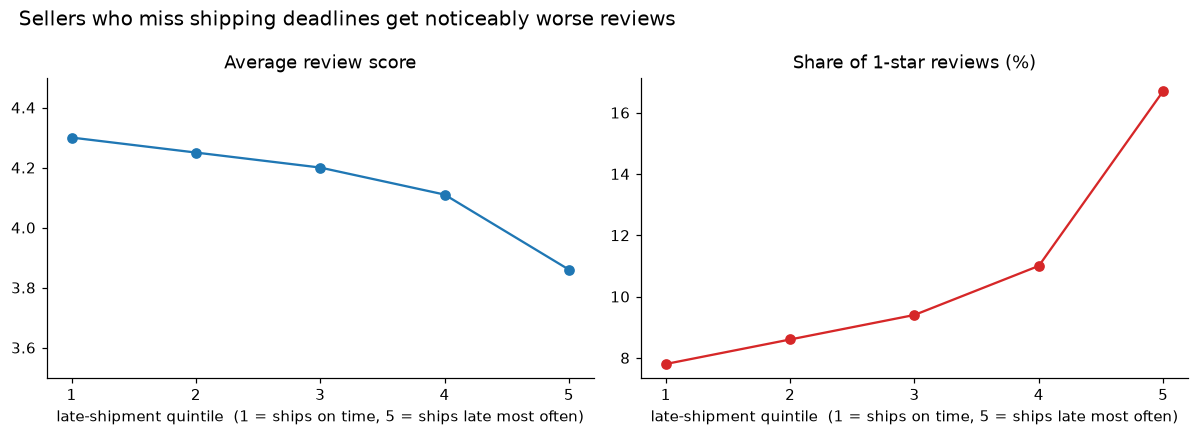

In [19]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


def save_fig(name):
    plt.savefig(FIGURES_DIR / name, dpi=200, bbox_inches="tight")


d = late_vs_reviews
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

left.plot(d.quintile, d.avg_review_score, marker="o", color="C0")
left.set_title("Average review score")
left.set_ylim(3.5, 4.5)

right.plot(d.quintile, d.avg_pct_1star, marker="o", color="C3")
right.set_title("Share of 1-star reviews (%)")

for ax in (left, right):
    ax.set_xlabel("late-shipment quintile  (1 = ships on time, 5 = ships late most often)")
    ax.set_xticks(d.quintile)

fig.suptitle("Sellers who miss shipping deadlines get noticeably worse reviews",
             x=0.02, ha="left", fontsize=13)
fig.tight_layout()
save_fig("01_late_shipment_vs_reviews.png")
plt.show()

The on-time quintile never misses a deadline and averages a 4.30 review score
with 7.8% 1-star. The worst quintile misses on a third of orders (32% average)
and drops to 3.86 and 16.7% 1-star. Cancellations point the same way but are
rare: only 202 scored sellers ever cancel an order, and they average 3.96
against 4.18 for sellers that never cancel.

So the answer to Q1: seller performance moves the review score, and late
shipping is the part of it Olist can measure and act on.

## Q2: What share of low review scores the worst sellers account for

Each scored seller is put in one of three tiers from its own numbers:

- **keep**: average score at least 4.0 and late-shipment rate under 15%
- **remove**: average score under 3.0, or late-shipment rate 40% or higher, or
  cancellation rate 10% or higher
- **watch**: everything in between

In [20]:
%%sql tiers <<
WITH scored AS (
    SELECT * FROM seller_scorecard WHERE n_orders >= 10
),
tiered AS (
    SELECT *,
           CASE
               WHEN avg_score IS NULL THEN 'unrated'
               WHEN avg_score >= 4.0 AND coalesce(pct_late_ship, 0) < 15 THEN 'keep'
               WHEN avg_score < 3.0 OR coalesce(pct_late_ship, 0) >= 40
                    OR coalesce(pct_canceled, 0) >= 10 THEN 'remove'
               ELSE 'watch'
           END AS tier
    FROM scored
),
marketplace AS (
    SELECT count(*) FILTER (WHERE review_score = 1) AS all_1star
    FROM single_seller_orders s JOIN order_reviews r USING (order_id)
)
SELECT t.tier,
       count(*)                                                        AS sellers,
       round(100.0 * count(*) / sum(count(*)) OVER (), 1)              AS pct_sellers,
       sum(t.n_orders)                                                 AS orders,
       round(100.0 * sum(t.n_orders) / sum(sum(t.n_orders)) OVER (), 1) AS pct_orders,
       round(avg(t.avg_score), 2)                                      AS avg_score,
       round(100.0 * sum(t.n_1star) / any_value(m.all_1star), 1)       AS pct_of_marketplace_1star,
       round(100.0 * sum(t.n_1star) / sum(t.n_reviews), 1)             AS tier_1star_rate
FROM tiered t, marketplace m
GROUP BY t.tier
ORDER BY sellers DESC;

In [21]:
tiers

,tier,sellers,pct_sellers,orders,pct_orders,avg_score,pct_of_marketplace_1star,tier_1star_rate
0,keep,784,61.7,61140.0,65.1,4.35,46.2,8.1
1,watch,416,32.7,30571.0,32.6,3.89,40.5,14.3
2,remove,71,5.6,2209.0,2.4,3.40,5.7,28.0


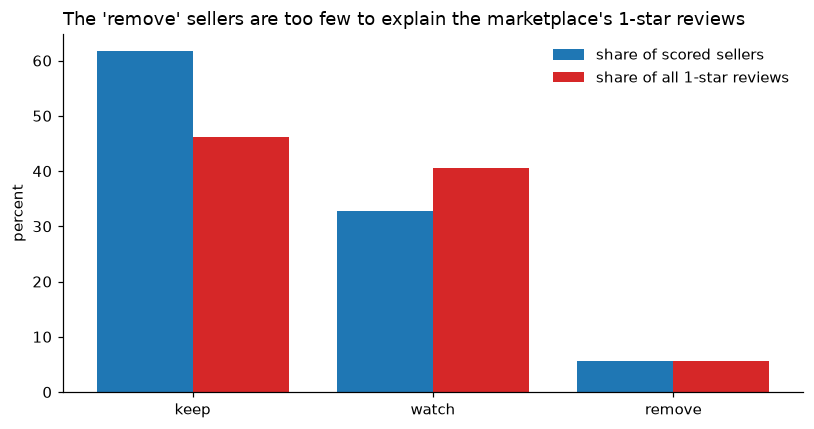

In [22]:
order = ["keep", "watch", "remove"]
t = tiers.set_index("tier").loc[order].reset_index()
x = range(len(t))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar([i - 0.2 for i in x], t.pct_sellers, 0.4, label="share of scored sellers", color="C0")
ax.bar([i + 0.2 for i in x], t.pct_of_marketplace_1star, 0.4,
       label="share of all 1-star reviews", color="C3")
ax.set_xticks(list(x))
ax.set_xticklabels(order)
ax.set_ylabel("percent")
ax.legend(frameon=False)
ax.set_title("The 'remove' sellers are too few to explain the marketplace's 1-star reviews",
             loc="left", fontsize=12)
fig.tight_layout()
save_fig("02_where_the_bad_reviews_are.png")
plt.show()

The **remove** tier is 5.6% of scored sellers and 2.4% of orders, and it
produces 5.7% of all 1-star reviews. The **watch** tier adds another 40.5%. The
**keep** tier, on its own, still produces 46% of the marketplace's 1-star
reviews, because it carries most of the volume and even good sellers get a 1-star
about 8% of the time.

Put differently: if every watch and remove seller were held to the keep tier's
1-star rate, the single-seller 1-star rate would fall from 10.6% to 8.1%. Real,
but not a rescue. Low review scores are spread across the whole seller base, not
concentrated in a bad corner of it.

## Q3: What Olist should do

Removing sellers barely moves the number, so the work is mostly coaching and
enforcement, plus tighter onboarding. The onboarding case is in the volume
split: sellers with fewer than 10 orders average 3.96, below the 4.15 that
sellers settle at once they pass 10.

In [23]:
%%sql volume <<
SELECT
  CASE WHEN n_orders < 10  THEN '1: <10'
       WHEN n_orders < 50  THEN '2: 10-49'
       WHEN n_orders < 200 THEN '3: 50-199'
       ELSE '4: 200+' END           AS volume_bucket,
  count(*)                          AS sellers,
  round(avg(avg_score), 2)          AS avg_review_score,
  round(avg(pct_1star), 1)          AS avg_pct_1star,
  round(avg(pct_late_ship), 1)      AS avg_pct_late_ship
FROM seller_scorecard
GROUP BY volume_bucket
ORDER BY volume_bucket;

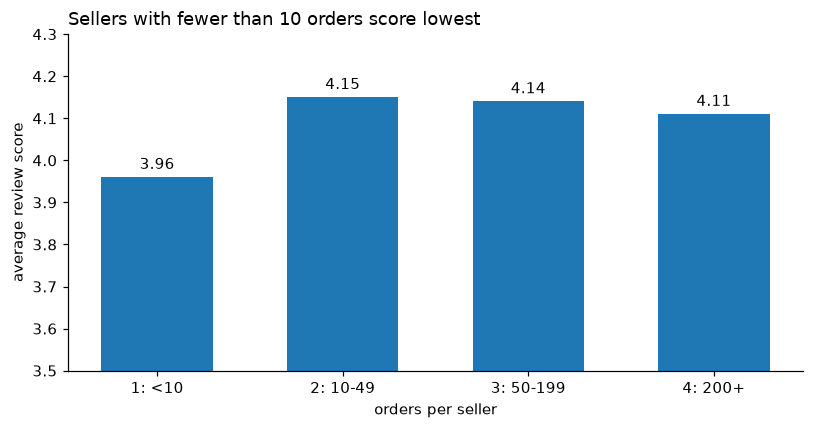

In [24]:
v = volume
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(v.volume_bucket, v.avg_review_score, color="C0", width=0.6)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylim(3.5, 4.3)
ax.set_ylabel("average review score")
ax.set_xlabel("orders per seller")
ax.set_title("Sellers with fewer than 10 orders score lowest", loc="left", fontsize=12)
fig.tight_layout()
save_fig("03_new_sellers_score_lower.png")
plt.show()

## Recommendation

1. **Enforce the shipping deadline.** Late shipping is the seller behaviour that
   tracks review scores most cleanly, and `shipping_limit_date` is already in the
   data. Flag sellers whose late rate crosses 15% and escalate at 40%.
2. **Coach the watch tier, don't cut it.** It is a third of orders and a third of
   1-star reviews. Moving it toward the keep tier's shipping and rating is where
   the marketplace-level gain is.
3. **Remove the 71-seller tail only after a warning.** It is 2.4% of orders, so
   removal is low risk, but it is also a small share of the problem, so it is not
   urgent. Most of these sellers are in SP (41 of 71).
4. **Tighten onboarding.** New and very small sellers score below the settled
   base. A probation period with a shipping SLA would catch the weak ones before
   they collect 1-star reviews.

On incentives: the dataset has no fee, cost, or margin data, so whether a
bonus for on-time shipping would beat plain enforcement can't be tested here.

The three starting questions, answered: seller performance reaches Olist through
review scores, driven mostly by late shipping; the worst sellers are a small
share of the low scores; and the response is enforcement and coaching, with
removal reserved for a short list.

Standalone copies of the staging views and the scorecard query are in
`02-seller-quality/sql/` for reference outside the notebook.